# Dataset generation

| Var             | Range | Unit | Description                             |
|-----------------|-------|------|-----------------------------------------|
| $\eta_{PV}$     | 5-20  |      | panel efficiency                        |
| $\eta_{UGC}$    | 80-95 |      | PMU efficiency                          |
| $\eta_{B}$      | 80-90 |      | battery efficiency                      |
| $\eta_{STC}$    | 19-22 | %    | nominal efficiency of energy conversion |
| $A_{\text{PV}}$ |       | m²   | photovoltaic panel surface              |
| Ppv             |       | W    | panel power output                      |
| G(h)            |       | W/m² | hourly solar irradiance                 |
| Pn              |       | W    | power demand                            |
| Ppmu            |       | W    | PMU power                               |
| Pb              |       | W    | battery power                           |

In [49]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Panel generation

In [50]:
# load panels from panels.csv
panels_raw = pd.read_csv('panel_areas.csv')
panels_raw['Apv(m2)'] = (panels_raw['width_cm'].astype(float) / 100) * (panels_raw['height_cm'].astype(float) / 100)
Apv = sorted(panels_raw['Apv(m2)'].unique())
print(f"Loaded {len(panels_raw):,} panels, unique areas: {len(Apv)}")
display(panels_raw.head(10))

Loaded 120 panels, unique areas: 89


,width_cm,height_cm,Apv(m2)
0,1,1,0.0001
1,1,2,0.0002
2,1,3,0.0003
3,1,4,0.0004
4,1,5,0.0005
5,1,6,0.0006
6,1,7,0.0007
7,1,8,0.0008
8,1,9,0.0009
9,1,10,0.0010


In [51]:
# generate panels

eta_stc = [x / 10 for x in range(190, 221, 5)]
panels = list(itertools.product(Apv, eta_stc))
panels_df = pd.DataFrame(panels, columns=['Apv(m2)', 'eta_stc(%)'])
panels_df['Panel_ID'] = range(0, len(panels_df))
panels_df = panels_df[['Panel_ID', 'Apv(m2)', 'eta_stc(%)']]

print(f"# possible panels: {len(Apv)} × {len(eta_stc)} = {len(panels_df):,}")
print("First 10:")
display(panels_df.head(10))


# possible panels: 89 × 7 = 623
First 10:


,Panel_ID,Apv(m2),eta_stc(%)
0,0,0.0001,19.0
1,1,0.0001,19.5
2,2,0.0001,20.0
3,3,0.0001,20.5
4,4,0.0001,21.0
5,5,0.0001,21.5
6,6,0.0001,22.0
7,7,0.0002,19.0
8,8,0.0002,19.5
9,9,0.0002,20.0


## Irradiance data

Load irradiance data from CSV file with hourly data for the whole year.

In [52]:
# Column name constants (use these everywhere to refer to CSV columns)
COL_RAW_DATETIME = 'Date-hour'  # original datetime
COL_MONTH = 'Month'
COL_DAY = 'Day'
COL_HOUR = 'Hour'
COL_G = 'G(h)'
COL_TEMP = 'Temperature'

In [53]:
try:
    # Columns: Month, Day, Hour, G(h), Temperature
    orig_data = pd.read_csv('irradiance.csv', usecols=[0,1,2,3,4,5])

    # Rename columns to standard constants
    # CSV header has: Date-hour, Month, Day, Hour, G(h), Temperature
    orig_data.columns = [COL_RAW_DATETIME, COL_MONTH, COL_DAY, COL_HOUR, COL_G, COL_TEMP]

    print("📊 IRRADIANCE DATA")
    print(f"Total records: {len(orig_data):,}")
    print(f"Available columns: {list(orig_data.columns)}")
    print(f"Dataset shape: {orig_data.shape}")
    print(f"Months: {orig_data[COL_MONTH].min()} - {orig_data[COL_MONTH].max()}")
    print(f"Days: {orig_data[COL_DAY].min()} - {orig_data[COL_DAY].max()}")

    # Show basic statistics for G(h)
    gh_column = COL_G  # use constant
    print(f"\n🌞 IRRADIANCE STATISTICS {gh_column}:")
    print(f"Min: {orig_data[gh_column].min():.2f} W/m²")
    print(f"Max: {orig_data[gh_column].max():.2f} W/m²")
    print(f"Mean: {orig_data[gh_column].mean():.2f} W/m²")
    print(f"Records with {gh_column} > 0: {(orig_data[gh_column] > 0).sum():,}")

    print(f"\n🔍 FIRST 5 ROWS:")
    display(orig_data.head())

    print(f"\n📊 COLUMN INFO:")
    display(orig_data.info())
except FileNotFoundError:
    print("❌ Error: 'irradiance.csv' file not found")
    print("Make sure the file is in the current working directory")
except Exception as e:
    print(f"❌ Error loading file: {e}")

📊 IRRADIANCE DATA
Total records: 8,760
Available columns: ['Date-hour', 'Month', 'Day', 'Hour', 'G(h)', 'Temperature']
Dataset shape: (8760, 6)
Months: 1 - 12
Days: 1 - 31

🌞 IRRADIANCE STATISTICS G(h):
Min: 0.00 W/m²
Max: 1045.00 W/m²
Mean: 184.93 W/m²
Records with G(h) > 0: 4,400

🔍 FIRST 5 ROWS:


,Date-hour,Month,Day,Hour,G(h),Temperature
0,20210101-0000,1,1,0,0,5.47
1,20210101-0100,1,1,1,0,4.94
2,20210101-0200,1,1,2,0,4.40
3,20210101-0300,1,1,3,0,3.87
4,20210101-0400,1,1,4,0,3.34



📊 COLUMN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date-hour    8760 non-null   object 
 1   Month        8760 non-null   int64  
 2   Day          8760 non-null   int64  
 3   Hour         8760 non-null   int64  
 4   G(h)         8760 non-null   int64  
 5   Temperature  8760 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 410.8+ KB


None

In [54]:
# --- Detect and remove nighttime (all-zero) hours while preserving original `orig_data` ---
# Determine which 'Hour' values have G(h) == 0 for every record (full-year) and create `data` (filtered) without those rows.

gh_col = COL_G  # G(h) column name
hour_col = COL_HOUR  # Hour column name

# Work on a copy to avoid mutating orig_data in-place
data = orig_data.copy()

# Ensure Hour is integer
data[hour_col] = data[hour_col].astype(int)

# For each hour (0-23), check if all G(h) values are zero across the dataset
hour_all_zero = data.groupby(hour_col)[gh_col].apply(lambda x: (x == 0).all())
zero_hours = sorted([int(h) for h, all_zero in hour_all_zero.items() if all_zero])

# Merge consecutive hours into ranges for clearer reporting
zero_ranges = []
start = prev = zero_hours[0]
for h in zero_hours[1:]:
    if h == prev + 1:
        prev = h
        continue
    else:
        zero_ranges.append((start, prev))
        start = prev = h
zero_ranges.append((start, prev))

print(f"Detected zero-only hours: {zero_hours}")
print(f"Merged zero-hour ranges: {zero_ranges}")

# Create final filtered `data`
data = data[~data[hour_col].isin(zero_hours)].reset_index(drop=True)
removed_rows = len(orig_data) - len(data)
print(f"Original rows: {len(orig_data):,}, removed: {removed_rows:,}  , remaining: {len(data):,})")


Detected zero-only hours: [0, 1, 2, 3, 4, 20, 21, 22, 23]
Merged zero-hour ranges: [(0, 4), (20, 23)]
Original rows: 8,760, removed: 3,285  , remaining: 5,475)


## Power calculation

In [55]:
def panel_power(Gh, Apv, nstc):
    return Gh * Apv * nstc

In [56]:
def get_irradiance(day, hour):
    if not (1 <= day <= 31 and 0 <= hour <= 23):
        return None

    row = data[(data[COL_DAY] == day) & (data[COL_HOUR] == hour)]
    if row.empty:
        return None

    gh_column = COL_G  # G(h) - W/m2
    return row.iloc[0][gh_column]

In [57]:
# Calculate the power of each panel for each irradiance value

panel_powers = []
for idx, panel in panels_df.iterrows():
    Apv = panel['Apv(m2)']
    nstc = panel['eta_stc(%)'] / 100  # convert to fraction

    powers = []
    for Gh in data[COL_G]:
        powers.append(panel_power(Gh, Apv, nstc))
    panel_powers.append(powers)

panel_powers = pd.DataFrame(panel_powers)
panel_powers.index = panels_df['Panel_ID']
panel_powers.columns = [f"Gh_{i}" for i in range(len(panel_powers.columns))]

print("Power calculated for all panels and all irradiance values.")
display(panel_powers.head())

Power calculated for all panels and all irradiance values.


,Gh_0,Gh_1,Gh_2,Gh_3,Gh_4,Gh_5,Gh_6,Gh_7,Gh_8,Gh_9,...,Gh_5465,Gh_5466,Gh_5467,Gh_5468,Gh_5469,Gh_5470,Gh_5471,Gh_5472,Gh_5473,Gh_5474
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.001159,0.004218,0.006422,0.008493,0.000931,0.008759,0.000057,...,0.005415,0.000076,0.008626,0.000912,0.007106,0.004218,0.001425,0.0,0.0,0.0
1,0.0,0.0,0.0,0.001190,0.004329,0.006591,0.008717,0.000955,0.008990,0.000059,...,0.005558,0.000078,0.008853,0.000936,0.007293,0.004329,0.001463,0.0,0.0,0.0
2,0.0,0.0,0.0,0.001220,0.004440,0.006760,0.008940,0.000980,0.009220,0.000060,...,0.005700,0.000080,0.009080,0.000960,0.007480,0.004440,0.001500,0.0,0.0,0.0
3,0.0,0.0,0.0,0.001251,0.004551,0.006929,0.009163,0.001004,0.009451,0.000062,...,0.005842,0.000082,0.009307,0.000984,0.007667,0.004551,0.001538,0.0,0.0,0.0
4,0.0,0.0,0.0,0.001281,0.004662,0.007098,0.009387,0.001029,0.009681,0.000063,...,0.005985,0.000084,0.009534,0.001008,0.007854,0.004662,0.001575,0.0,0.0,0.0


In [58]:
# Calculate the total energy generated by each panel throughout the year (Wh)
# The energy per hour is equal to the power per hour (Wh)
total_panel_energy = panel_powers.sum(axis=1)
panels_with_energy = panels_df.copy()
panels_with_energy['Total_energy_Wh'] = total_panel_energy
print("Total energy generated by each panel throughout the year (Wh):")
display(panels_with_energy[['Panel_ID', 'Apv(m2)', 'eta_stc(%)', 'Total_energy_Wh']].head())

Total energy generated by each panel throughout the year (Wh):


,Panel_ID,Apv(m2),eta_stc(%),Total_energy_Wh
0,0,0.0001,19.0,30.78038
1,1,0.0001,19.5,31.59039
2,2,0.0001,20.0,32.40040
3,3,0.0001,20.5,33.21041
4,4,0.0001,21.0,34.02042


In [59]:
# Calculate daily energy generated by each panel (Wh/day)
num_days = len(panel_powers.columns) // 24
day_labels = [f"day_{(i//24+1):03d}" for i in range(len(panel_powers.columns))]
panel_daily_energy = panel_powers.copy()
panel_daily_energy.columns = day_labels
panel_daily_energy = panel_daily_energy.T.groupby(level=0).sum().T
panel_daily_energy.index = panels_df['Panel_ID']
print("Daily energy generated by each panel (Wh/day):")
display(panel_daily_energy.head())

Daily energy generated by each panel (Wh/day):


,day_001,day_002,day_003,day_004,day_005,day_006,day_007,day_008,day_009,day_010,...,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,0.068438,0.060914,0.055119,0.048735,0.021432,0.056430,0.066063,0.105944,0.060097,0.104367,...,0.045144,0.053903,0.059964,0.090079,0.027265,0.049590,0.055917,0.068343,0.076209,0.0
1,0.070239,0.062517,0.056570,0.050018,0.021996,0.057915,0.067802,0.108732,0.061679,0.107114,...,0.046332,0.055322,0.061542,0.092450,0.027983,0.050895,0.057389,0.070142,0.078215,0.0
2,0.072040,0.064120,0.058020,0.051300,0.022560,0.059400,0.069540,0.111520,0.063260,0.109860,...,0.047520,0.056740,0.063120,0.094820,0.028700,0.052200,0.058860,0.071940,0.080220,0.0
3,0.073841,0.065723,0.059470,0.052583,0.023124,0.060885,0.071278,0.114308,0.064841,0.112606,...,0.048708,0.058159,0.064698,0.097190,0.029417,0.053505,0.060331,0.073738,0.082225,0.0
4,0.075642,0.067326,0.060921,0.053865,0.023688,0.062370,0.073017,0.117096,0.066423,0.115353,...,0.049896,0.059577,0.066276,0.099561,0.030135,0.054810,0.061803,0.075537,0.084231,0.0


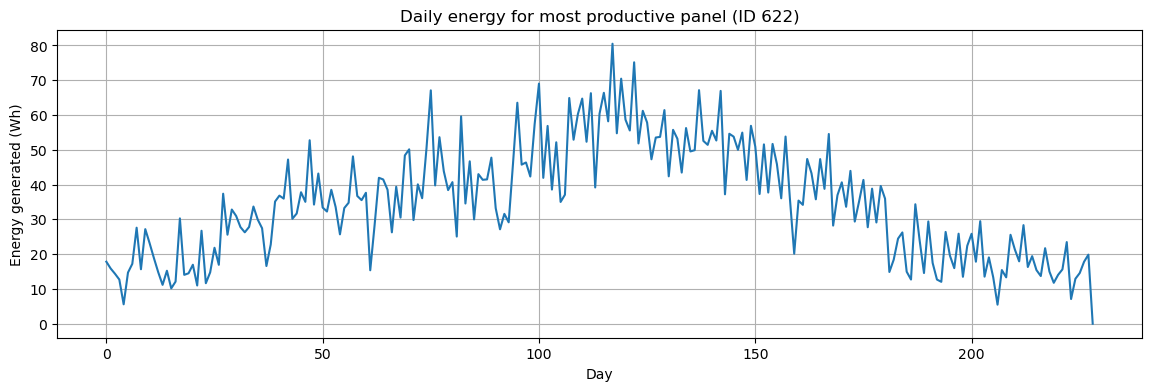

In [60]:
# Plot daily energy for the most productive panel
most_productive_panel_id = panel_daily_energy.sum(axis=1).idxmax()
energy_per_day = panel_daily_energy.loc[most_productive_panel_id]
plt.figure(figsize=(14,4))
plt.plot(energy_per_day.values)
plt.title(f"Daily energy for most productive panel (ID {most_productive_panel_id})")
plt.xlabel("Day")
plt.ylabel("Energy generated (Wh)")
plt.grid(True)
plt.show()